<a href="https://colab.research.google.com/github/Kkurzo/-labs/blob/main/%22%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_%D0%9C%D0%9D_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%85_%D1%80%D1%8F%D0%B4%D1%96%D0%B2_%D0%A2%D1%80%D0%B5%D0%BD_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9C%D0%B5%D0%BB%D1%8C%D0%BD%D0%B8%D1%87%D1%83%D0%BA_%D0%A4%D0%86%D0%A2_4_10_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практикум: аналіз і прогнозування часових рядів

Цей notebook доповнює лекцію **«Аналіз і прогнозування часових рядів. Навчання та оцінка моделі»**.

Мета практикуму — послідовно пройти основні етапи прогнозування:

1. підготовка часових даних;
2. візуальний аналіз;
3. дослідження тренду та сезонності;
4. коректний часовий поділ на train/test;
5. побудова базових прогнозів;
6. оцінювання якості за MAE, RMSE, sMAPE та MASE;
7. застосування ETS;
8. застосування SARIMA;
9. використання Prophet;
10. побудова ML-моделі на лагових і календарних ознаках;
11. покрокова ретроспективна перевірка;
12. самостійні завдання.

**Важливо:** у часових рядах не можна випадково перемішувати спостереження перед поділом на навчальну і тестову вибірки.

## 1. Підключення бібліотек

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

pd.set_option("display.max_columns", 50)
np.random.seed(42)

## 2. Формування навчального часового ряду

Щоб notebook можна було виконувати без завантаження зовнішніх файлів, використаємо штучно сформований щоденний ряд продажів. Він містить:

- довгостроковий тренд;
- тижневу сезонність;
- річну сезонність;
- підвищення попиту у вихідні;
- випадковий шум;
- декілька аномальних значень.

Такий ряд зручний для демонстрації основних етапів forecasting.

In [3]:
dates = pd.date_range("2022-01-01", "2025-12-31", freq="D")
n = len(dates)
t = np.arange(n)

trend = 100 + 0.035 * t
weekly = 12 * np.sin(2 * np.pi * t / 7)
yearly = 8 * np.sin(2 * np.pi * t / 365.25)
weekend = np.where(dates.dayofweek >= 5, 10, 0)
noise = np.random.normal(0, 6, n)

sales = trend + weekly + yearly + weekend + noise

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

# Додаємо кілька пропусків та аномалій для демонстрації підготовки даних
missing_idx = [120, 450, 900]
outlier_idx = [300, 700, 1100]

df.loc[missing_idx, "sales"] = np.nan
df.loc[outlier_idx, "sales"] *= 1.7

df.head()

,date,sales
0,2022-01-01,112.980285
1,2022-01-02,118.725005
2,2022-01-03,115.930451
3,2022-01-04,114.862459
4,2022-01-05,94.078518


In [4]:
print(df.shape)
print(df.dtypes)
print("\nКількість пропусків:")
print(df.isna().sum())

(1461, 2)
date     datetime64[ns]
sales           float64
dtype: object

Кількість пропусків:
date     0
sales    3
dtype: int64


### Завдання 1. Первинний аналіз

1. Виведіть останні 10 рядків.
2. Визначте мінімальну та максимальну дату.
3. Обчисліть середнє, медіану, стандартне відхилення, мінімум і максимум `sales`.
4. Перевірте, чи є дублікати дат.

In [5]:
# 1. Останні 10 рядків
print("Останні 10 рядків:")
display(df.tail(10))

# 2. Мінімальна та максимальна дати
print("Мінімальна дата:", df["date"].min().date())
print("Максимальна дата:", df["date"].max().date())

# 3. Основні статистичні характеристики
stats = df["sales"].agg(["mean", "median", "std", "min", "max"])
print("\nОписові статистики:")
display(stats.to_frame("sales"))

# 4. Перевірка дублікатів дат
duplicates = df["date"].duplicated().sum()
print("Кількість дублікатів дат:", duplicates)

Останні 10 рядків:


,date,sales
1451,2025-12-22,171.328008
1452,2025-12-23,156.237492
1453,2025-12-24,160.161011
1454,2025-12-25,141.622914
1455,2025-12-26,130.154195
1456,2025-12-27,164.792801
1457,2025-12-28,172.113885
1458,2025-12-29,170.054977
1459,2025-12-30,160.035508
1460,2025-12-31,144.925047


Мінімальна дата: 2022-01-01
Максимальна дата: 2025-12-31

Описові статистики:


,sales
mean,128.868405
median,128.307405
std,19.969577
min,78.054031
max,279.572480


Кількість дублікатів дат: 0


## 3. Підготовка часових даних

Для подальшого аналізу необхідно:

- перетворити дату у формат `datetime`;
- відсортувати дані;
- зробити дату індексом;
- перевірити регулярність часового кроку;
- обробити пропущені значення.

У цьому прикладі пропуски заповнюються часовою інтерполяцією.

In [6]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").drop_duplicates(subset="date")
df = df.set_index("date")

print(pd.infer_freq(df.index))

df["sales"] = df["sales"].interpolate(method="time")

print("Пропусків після інтерполяції:", df["sales"].isna().sum())
df.head()

D
Пропусків після інтерполяції: 0


,sales
date,
2022-01-01,112.980285
2022-01-02,118.725005
2022-01-03,115.930451
2022-01-04,114.862459
2022-01-05,94.078518


### Завдання 2. Робота з пропусками

Створіть копію набору даних `df_task` і штучно видаліть значення `sales` для п'яти довільних дат.

Порівняйте три способи заповнення:

- `ffill`;
- лінійну інтерполяцію;
- часову інтерполяцію.

Коротко поясніть, який спосіб доцільніший для цього ряду.

In [7]:
df_task = df.copy()

# Для відтворюваності обираємо конкретні позиції
gap_positions = [50, 250, 500, 800, 1200]
gap_dates = df_task.index[gap_positions]
df_task.loc[gap_dates, "sales"] = np.nan

comparison_missing = pd.DataFrame(index=gap_dates)
comparison_missing["ffill"] = df_task["sales"].ffill().loc[gap_dates]
comparison_missing["linear"] = df_task["sales"].interpolate(method="linear").loc[gap_dates]
comparison_missing["time"] = df_task["sales"].interpolate(method="time").loc[gap_dates]

display(comparison_missing)

print(
    "Висновок: для регулярного щоденного ряду лінійна та часова інтерполяція "
    "дають близькі результати. Часова інтерполяція є природним вибором, оскільки "
    "безпосередньо враховує часовий індекс. ffill може створювати штучні плато."
)

,ffill,linear,time
date,,,
2022-02-20,107.109464,112.217676,112.217676
2022-09-08,98.663180,98.094055,98.094055
2023-05-16,126.828583,128.193839,128.193839
2024-03-11,154.917374,146.277717,146.277717
2025-04-15,169.680889,155.852006,155.852006


Висновок: для регулярного щоденного ряду лінійна та часова інтерполяція дають близькі результати. Часова інтерполяція є природним вибором, оскільки безпосередньо враховує часовий індекс. ffill може створювати штучні плато.


## 4. Візуальний аналіз

Графік часового ряду є першим інструментом діагностики. За ним оцінюють:

- загальний напрям зміни;
- сезонні коливання;
- можливі структурні зміни;
- викиди;
- зміну дисперсії.

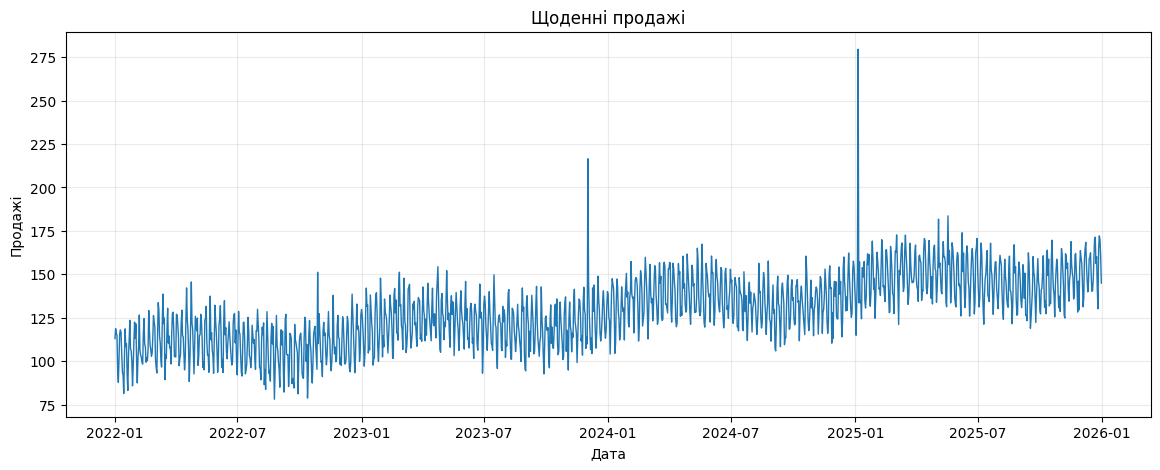

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["sales"], linewidth=1)
ax.set_title("Щоденні продажі")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажі")
ax.grid(alpha=0.25)
plt.show()

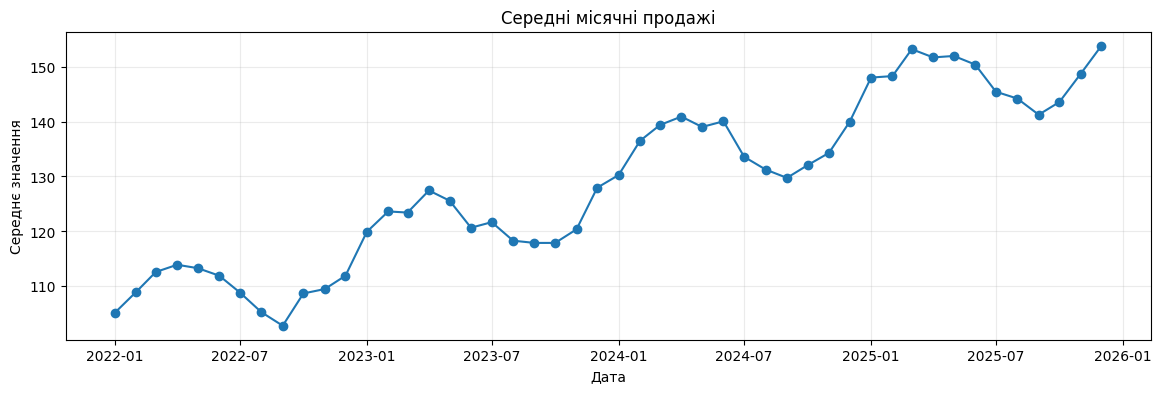

In [9]:
monthly = df["sales"].resample("MS").mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, marker="o")
ax.set_title("Середні місячні продажі")
ax.set_xlabel("Дата")
ax.set_ylabel("Середнє значення")
ax.grid(alpha=0.25)
plt.show()

### Завдання 3. Візуалізація

1. Побудуйте графік останніх 90 днів.
2. Побудуйте 7-денне та 30-денне ковзні середні.
3. Поясніть, чим відрізняється інформація на цих двох графіках.

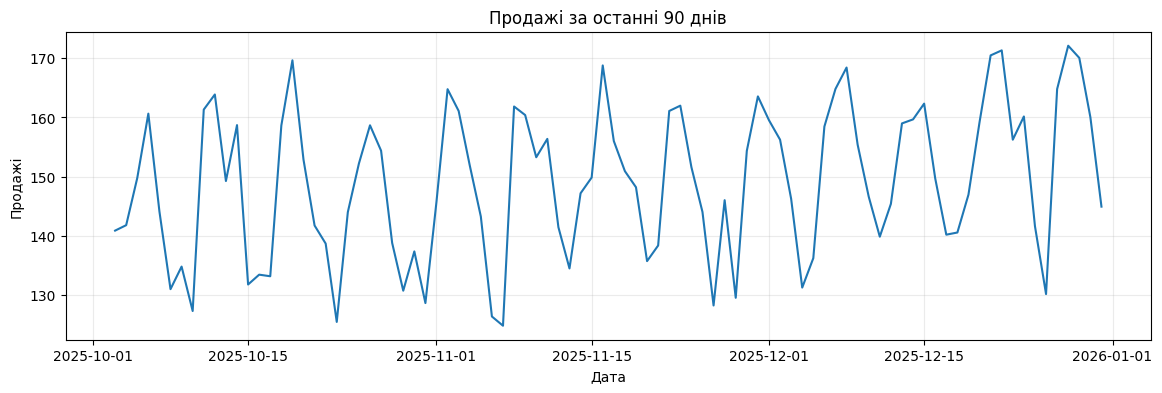

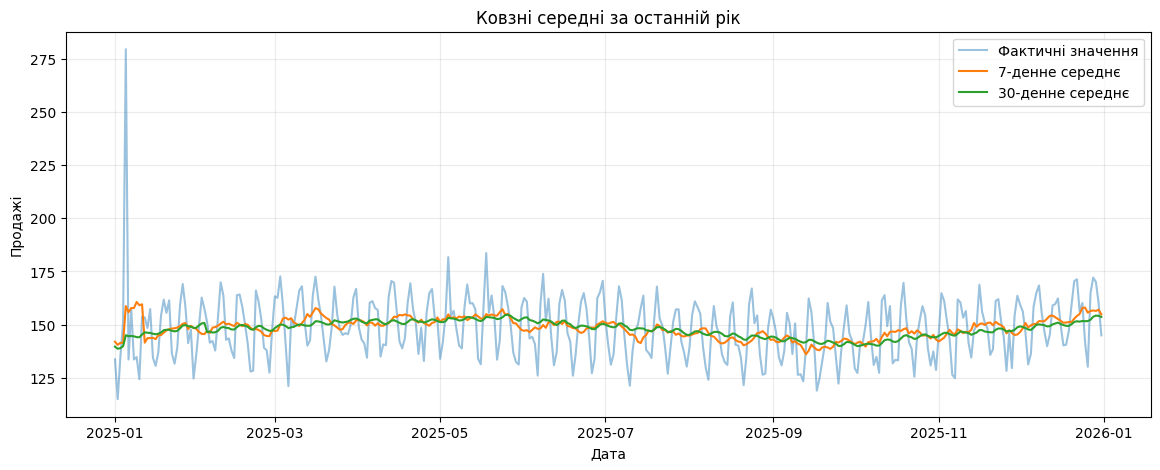

7-денне середнє швидше реагує на короткострокові зміни, тоді як 30-денне сильніше згладжує коливання і краще показує загальний тренд.


In [10]:
# 1. Останні 90 днів
last_90 = df["sales"].iloc[-90:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last_90.index, last_90.values)
ax.set_title("Продажі за останні 90 днів")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажі")
ax.grid(alpha=0.25)
plt.show()

# 2. Ковзні середні
rolling_7 = df["sales"].rolling(7).mean()
rolling_30 = df["sales"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-365:], df["sales"].iloc[-365:], alpha=0.45, label="Фактичні значення")
ax.plot(rolling_7.index[-365:], rolling_7.iloc[-365:], label="7-денне середнє")
ax.plot(rolling_30.index[-365:], rolling_30.iloc[-365:], label="30-денне середнє")
ax.set_title("Ковзні середні за останній рік")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажі")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(
    "7-денне середнє швидше реагує на короткострокові зміни, "
    "тоді як 30-денне сильніше згладжує коливання і краще показує загальний тренд."
)

## 5. Декомпозиція ряду методом STL

STL-декомпозиція розкладає часовий ряд на:

- **trend** — довгострокову тенденцію;
- **seasonal** — сезонну складову;
- **resid** — залишкову складову.

Для щоденних даних з тижневою сезонністю використаємо `period=7`.

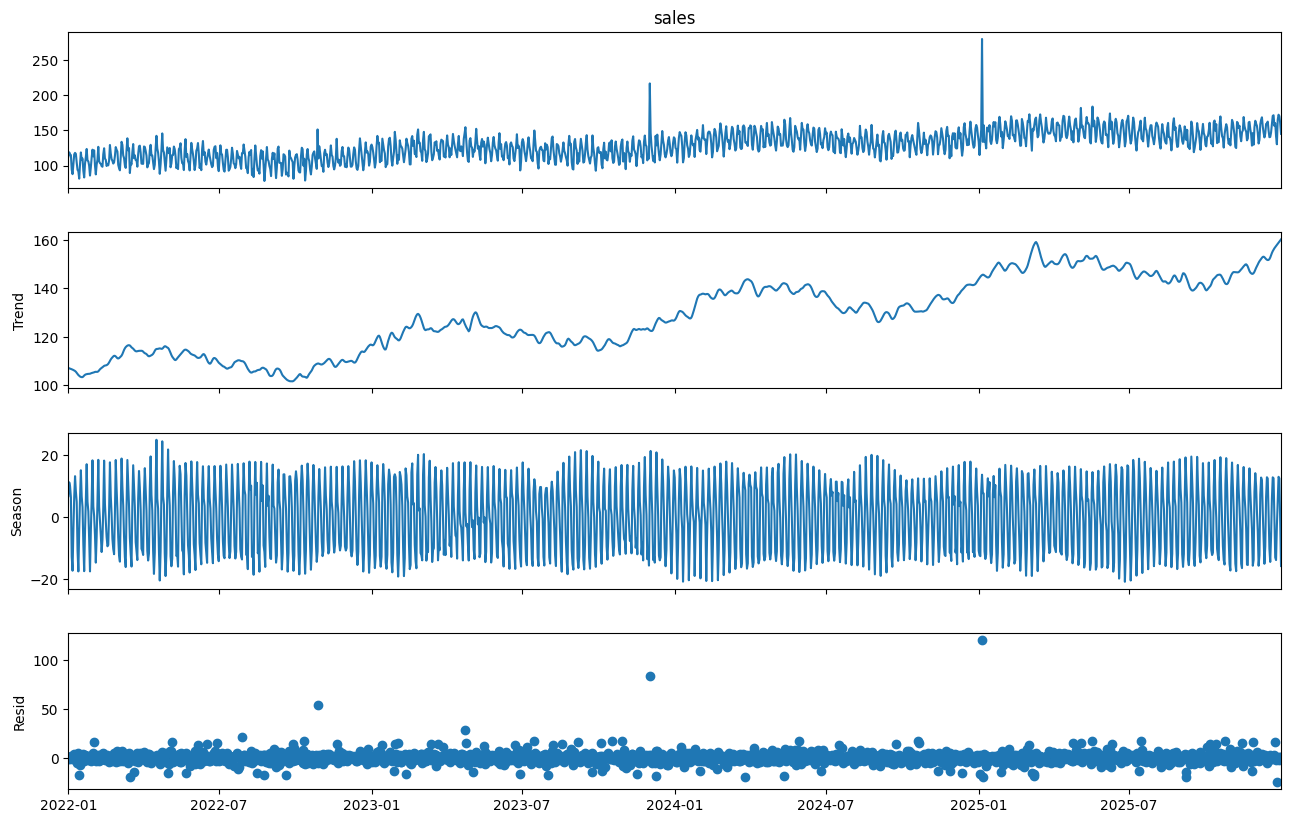

In [11]:
stl = STL(df["sales"], period=7, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 9)
plt.show()

### Завдання 4. Декомпозиція

1. Повторіть STL-декомпозицію для місячного ряду.
2. Оберіть обґрунтований період сезонності.
3. Проаналізуйте тренд та залишки.

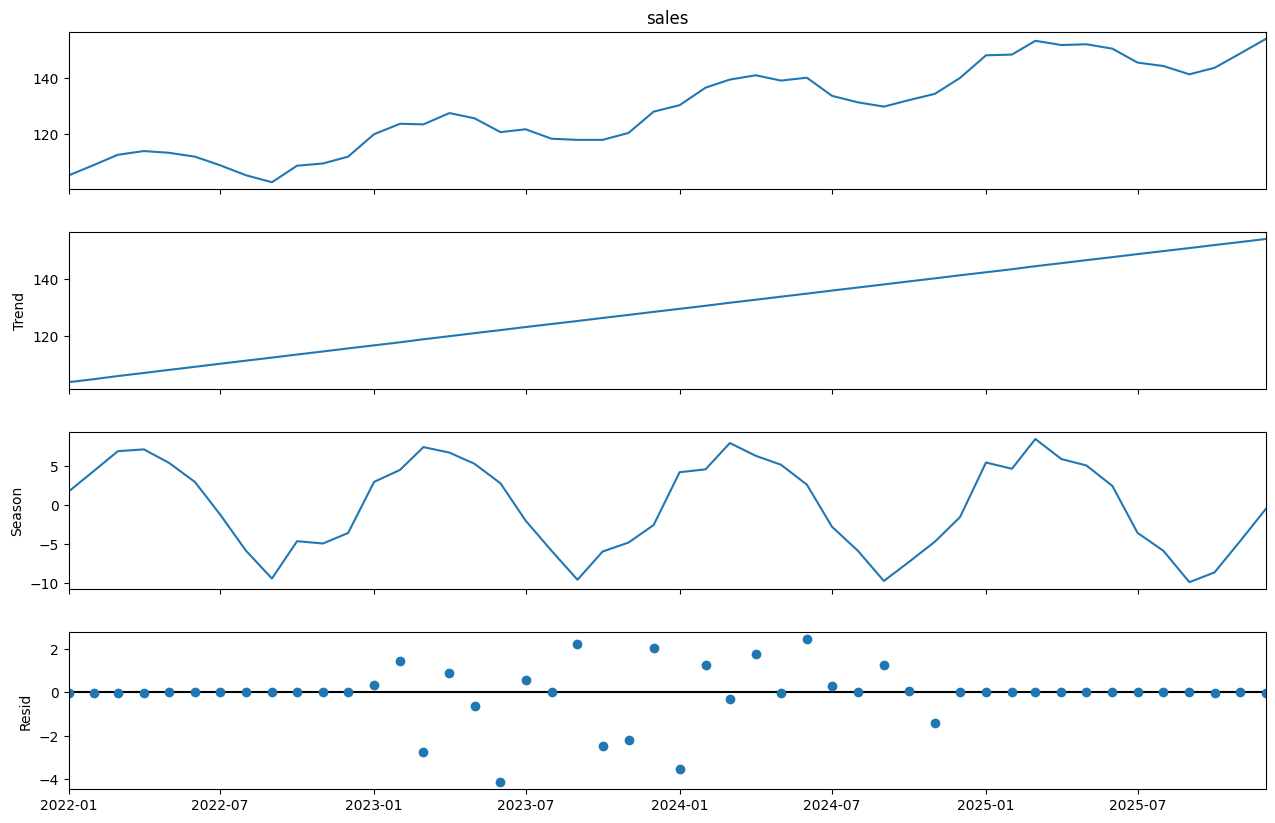

Для місячного ряду використано period=12, оскільки річний сезонний цикл містить 12 місяців. Тренд відображає поступове зростання рівня продажів, а залишки містять нерегулярні коливання, які не пояснюються трендом і сезонністю.


In [12]:
monthly_series = df["sales"].resample("MS").mean()

monthly_stl = STL(monthly_series, period=12, robust=True).fit()

fig = monthly_stl.plot()
fig.set_size_inches(14, 9)
plt.show()

print(
    "Для місячного ряду використано period=12, оскільки річний сезонний цикл "
    "містить 12 місяців. Тренд відображає поступове зростання рівня продажів, "
    "а залишки містять нерегулярні коливання, які не пояснюються трендом і сезонністю."
)

## 6. Часовий поділ train/test

У звичайних задачах машинного навчання дані часто перемішують. Для часових рядів це зазвичай неприпустимо.

Нехай останні 90 днів становлять тестовий період. Усі попередні спостереження використовуються для навчання.

In [13]:
horizon = 90

train = df.iloc[:-horizon].copy()
test = df.iloc[-horizon:].copy()

print("Train:", train.index.min().date(), "—", train.index.max().date(), len(train))
print("Test :", test.index.min().date(), "—", test.index.max().date(), len(test))

Train: 2022-01-01 — 2025-10-02 1371
Test : 2025-10-03 — 2025-12-31 90


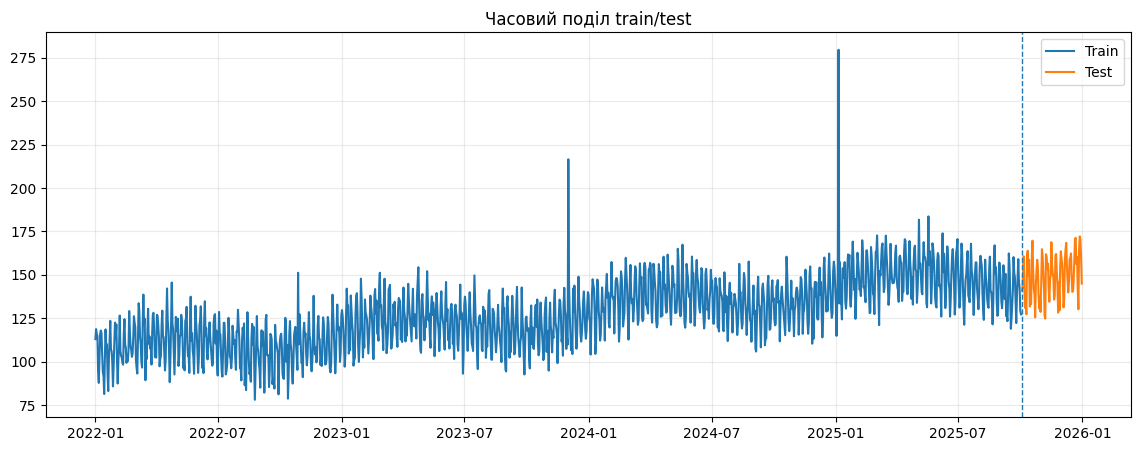

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train["sales"], label="Train")
ax.plot(test.index, test["sales"], label="Test")
ax.axvline(test.index.min(), linestyle="--", linewidth=1)
ax.legend()
ax.set_title("Часовий поділ train/test")
ax.grid(alpha=0.25)
plt.show()

### Завдання 5. Часовий поділ

Створіть інший варіант поділу, у якому тестовий період дорівнює 60 дням.

Виведіть:

- кількість спостережень у train;
- кількість спостережень у test;
- останню дату train;
- першу дату test.

In [15]:
horizon_60 = 60
train_60 = df.iloc[:-horizon_60].copy()
test_60 = df.iloc[-horizon_60:].copy()

print("Кількість спостережень у train:", len(train_60))
print("Кількість спостережень у test:", len(test_60))
print("Остання дата train:", train_60.index.max().date())
print("Перша дата test:", test_60.index.min().date())

Кількість спостережень у train: 1401
Кількість спостережень у test: 60
Остання дата train: 2025-11-01
Перша дата test: 2025-11-02


## 7. Базові моделі прогнозування

Перед використанням складної моделі потрібно побудувати простий базовий прогноз.

### Naive forecast
Прогноз дорівнює останньому відомому значенню.

### Seasonal naive
Прогноз повторює значення попереднього сезонного циклу. Для щоденних даних з тижневою сезонністю використаємо лаг 7.

In [16]:
naive_pred = np.repeat(train["sales"].iloc[-1], len(test))

history = pd.concat([train["sales"], test["sales"]])
seasonal_naive_pred = history.shift(7).loc[test.index].values

baseline = pd.DataFrame({
    "actual": test["sales"].values,
    "naive": naive_pred,
    "seasonal_naive": seasonal_naive_pred
}, index=test.index)

baseline.head()

,actual,naive,seasonal_naive
date,,,
2025-10-03,140.875312,127.213304,137.575710
2025-10-04,141.794922,127.213304,148.849817
2025-10-05,149.768594,127.213304,159.044241
2025-10-06,160.638161,127.213304,145.953075
2025-10-07,144.109047,127.213304,142.430282


## 8. Метрики якості прогнозу

Використаємо:

- **MAE** — середню абсолютну помилку;
- **RMSE** — квадратний корінь із середньоквадратичної помилки;
- **sMAPE** — симетричну відносну помилку;
- **MASE** — масштабовану абсолютну помилку.

Менше значення метрики зазвичай означає кращий прогноз.

In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return 100 * np.mean(
        2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
    )

def mase(y_true, y_pred, y_train, seasonality=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)

    scale = np.mean(
        np.abs(y_train[seasonality:] - y_train[:-seasonality])
    )
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate(y_true, y_pred, y_train, seasonality=7):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE_%": smape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train, seasonality)
    }

results = pd.DataFrame({
    "Naive": evaluate(test["sales"], naive_pred, train["sales"], 7),
    "Seasonal naive": evaluate(test["sales"], seasonal_naive_pred, train["sales"], 7)
}).T

results

,MAE,RMSE,sMAPE_%,MASE
Naive,22.039691,25.297086,15.570350,3.108885
Seasonal naive,7.734062,9.380056,5.276847,1.090955


### Завдання 6. Метрики

1. Визначте, яка базова модель є кращою.
2. Поясніть, чому висновок не слід робити лише за однією метрикою.
3. Обчисліть MAE окремо для перших і останніх 30 днів тестового періоду.

In [18]:
naive_metrics = evaluate(test["sales"], naive_pred, train["sales"], 7)
seasonal_metrics = evaluate(test["sales"], seasonal_naive_pred, train["sales"], 7)

baseline_compare = pd.DataFrame({
    "Naive": naive_metrics,
    "Seasonal naive": seasonal_metrics
}).T

display(baseline_compare)

best_baseline = baseline_compare["MAE"].idxmin()
print("Краща базова модель за MAE:", best_baseline)

first_30_actual = test["sales"].iloc[:30]
last_30_actual = test["sales"].iloc[-30:]

first_30_pred = baseline.loc[first_30_actual.index, "seasonal_naive"]
last_30_pred = baseline.loc[last_30_actual.index, "seasonal_naive"]

print(
    "MAE seasonal naive для перших 30 днів:",
    round(mean_absolute_error(first_30_actual, first_30_pred), 3)
)
print(
    "MAE seasonal naive для останніх 30 днів:",
    round(mean_absolute_error(last_30_actual, last_30_pred), 3)
)

print(
    "Висновок не слід робити лише за однією метрикою: MAE легко інтерпретується, "
    "RMSE сильніше штрафує великі помилки, sMAPE показує відносну похибку, "
    "а MASE дає змогу порівнювати модель з базовим масштабом помилки."
)

,MAE,RMSE,sMAPE_%,MASE
Naive,22.039691,25.297086,15.570350,3.108885
Seasonal naive,7.734062,9.380056,5.276847,1.090955


Краща базова модель за MAE: Seasonal naive
MAE seasonal naive для перших 30 днів: 8.155
MAE seasonal naive для останніх 30 днів: 6.768
Висновок не слід робити лише за однією метрикою: MAE легко інтерпретується, RMSE сильніше штрафує великі помилки, sMAPE показує відносну похибку, а MASE дає змогу порівнювати модель з базовим масштабом помилки.


## 9. Експоненційне згладжування ETS

Моделі ETS описують часовий ряд через рівень, тренд і сезонність.

Для навчального прикладу використаємо:

- адитивний тренд;
- адитивну сезонність;
- сезонний період 7 днів.

In [19]:
ets_model = ExponentialSmoothing(
    train["sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
).fit()

ets_pred = ets_model.forecast(len(test))

ets_metrics = evaluate(
    test["sales"],
    ets_pred,
    train["sales"],
    seasonality=7
)

ets_metrics

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


{'MAE': 13.11452610803631,
 'RMSE': np.float64(15.229020700077848),
 'sMAPE_%': np.float64(9.14961742586639),
 'MASE': np.float64(1.8499146745742305)}

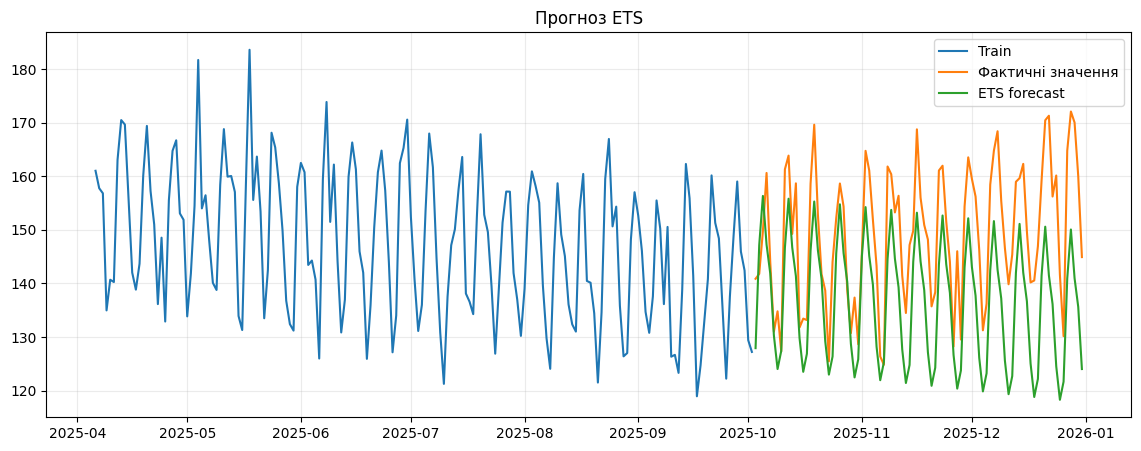

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train["sales"].iloc[-180:], label="Train")
ax.plot(test.index, test["sales"], label="Фактичні значення")
ax.plot(test.index, ets_pred, label="ETS forecast")
ax.legend()
ax.set_title("Прогноз ETS")
ax.grid(alpha=0.25)
plt.show()

### Завдання 7. ETS

1. Побудуйте ETS-модель без тренду.
2. Порівняйте її з поточною моделлю.
3. Додайте результати обох ETS-моделей до таблиці метрик.

In [21]:
ets_no_trend = ExponentialSmoothing(
    train["sales"],
    trend=None,
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
).fit()

ets_no_trend_pred = ets_no_trend.forecast(len(test))

ets_no_trend_metrics = evaluate(
    test["sales"],
    ets_no_trend_pred,
    train["sales"],
    seasonality=7
)

ets_compare = pd.DataFrame({
    "ETS з трендом": ets_metrics,
    "ETS без тренду": ets_no_trend_metrics
}).T

display(ets_compare)

print("Кращий варіант за MAE:", ets_compare["MAE"].idxmin())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,MAE,RMSE,sMAPE_%,MASE
ETS з трендом,13.114526,15.229021,9.149617,1.849915
ETS без тренду,8.894899,10.703167,6.091459,1.254701


Кращий варіант за MAE: ETS без тренду


## 10. SARIMA

SARIMA розширює ARIMA сезонними компонентами.

У загальному випадку модель записують як:

**SARIMA(p, d, q)(P, D, Q, s)**,

де `s` — довжина сезонного циклу.

Нижче використано невелику модель, щоб приклад виконувався відносно швидко.

In [22]:
sarima_model = SARIMAX(
    train["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.get_forecast(steps=len(test))
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

sarima_metrics = evaluate(
    test["sales"],
    sarima_pred,
    train["sales"],
    seasonality=7
)

sarima_metrics

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


{'MAE': 7.7465658208202095,
 'RMSE': np.float64(9.401756189500011),
 'sMAPE_%': np.float64(5.302245527656123),
 'MASE': np.float64(1.0927185375542505)}

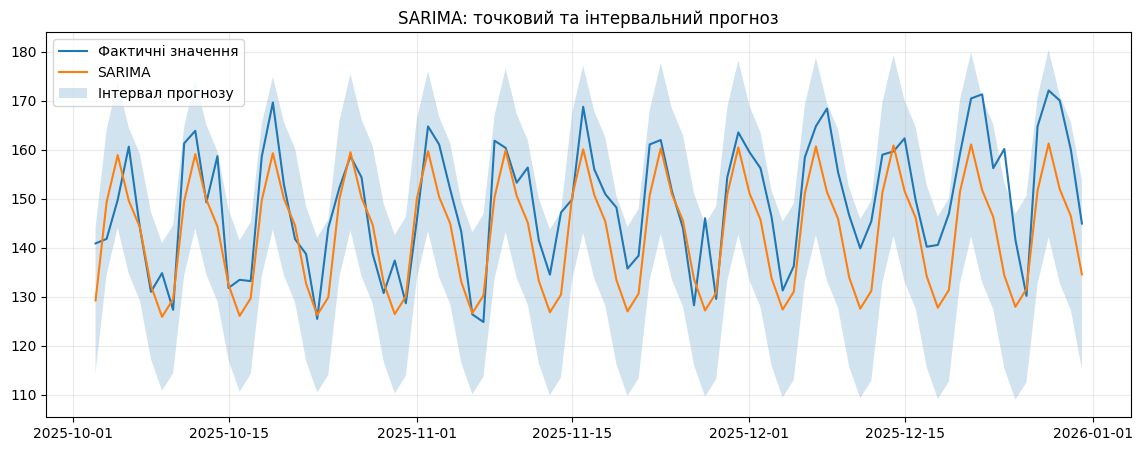

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test["sales"], label="Фактичні значення")
ax.plot(test.index, sarima_pred, label="SARIMA")
ax.fill_between(
    test.index,
    sarima_ci.iloc[:, 0].values,
    sarima_ci.iloc[:, 1].values,
    alpha=0.2,
    label="Інтервал прогнозу"
)
ax.legend()
ax.set_title("SARIMA: точковий та інтервальний прогноз")
ax.grid(alpha=0.25)
plt.show()

### Завдання 8. SARIMA

Змініть параметри моделі, наприклад:

- `order=(2, 1, 1)`;
- `seasonal_order=(1, 1, 0, 7)`.

Порівняйте MAE та RMSE з попередньою SARIMA-моделлю.

**Примітка:** мета завдання — зрозуміти вплив параметрів, а не виконати повний автоматичний підбір.

In [24]:
sarima_alt = SARIMAX(
    train["sales"],
    order=(2, 1, 1),
    seasonal_order=(1, 1, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_alt_pred = sarima_alt.get_forecast(steps=len(test)).predicted_mean

sarima_alt_metrics = evaluate(
    test["sales"],
    sarima_alt_pred,
    train["sales"],
    seasonality=7
)

sarima_compare = pd.DataFrame({
    "SARIMA (1,1,1)(1,0,1,7)": sarima_metrics,
    "SARIMA (2,1,1)(1,1,0,7)": sarima_alt_metrics
}).T

display(sarima_compare)
print("Краща конфігурація за MAE:", sarima_compare["MAE"].idxmin())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,MAE,RMSE,sMAPE_%,MASE
"SARIMA (1,1,1)(1,0,1,7)",7.746566,9.401756,5.302246,1.092719
"SARIMA (2,1,1)(1,1,0,7)",8.092037,9.663575,5.528950,1.141450


Краща конфігурація за MAE: SARIMA (1,1,1)(1,0,1,7)


## 11. Prophet

Prophet зручно використовувати для рядів з трендом, сезонністю та календарними ефектами.

У Prophet назви основних стовпців мають бути:

- `ds` — дата;
- `y` — цільове значення.

Якщо бібліотека не встановлена, у Google Colab її можна встановити командою:

```python
!pip -q install prophet
```

In [25]:
# Розкоментуйте, якщо Prophet встановлений.

# from prophet import Prophet
#
# prophet_train = (
#     train.reset_index()
#          .rename(columns={"date": "ds", "sales": "y"})
# )
#
# model_prophet = Prophet(
#     weekly_seasonality=True,
#     yearly_seasonality=True,
#     daily_seasonality=False,
#     seasonality_mode="additive"
# )
#
# model_prophet.fit(prophet_train)
#
# future = model_prophet.make_future_dataframe(
#     periods=len(test),
#     freq="D"
# )
#
# forecast = model_prophet.predict(future)
#
# prophet_pred = (
#     forecast.set_index("ds")
#             .loc[test.index, "yhat"]
# )
#
# evaluate(
#     test["sales"],
#     prophet_pred,
#     train["sales"],
#     seasonality=7
# )

### Завдання 9. Prophet

Після встановлення `prophet`:

1. навчіть модель;
2. отримайте прогноз на тестовий період;
3. побудуйте графік;
4. виведіть компоненти моделі;
5. порівняйте MAE з ETS та SARIMA.

,Prophet
MAE,5.301959
RMSE,6.437513
sMAPE_%,3.619983
MASE,0.747886


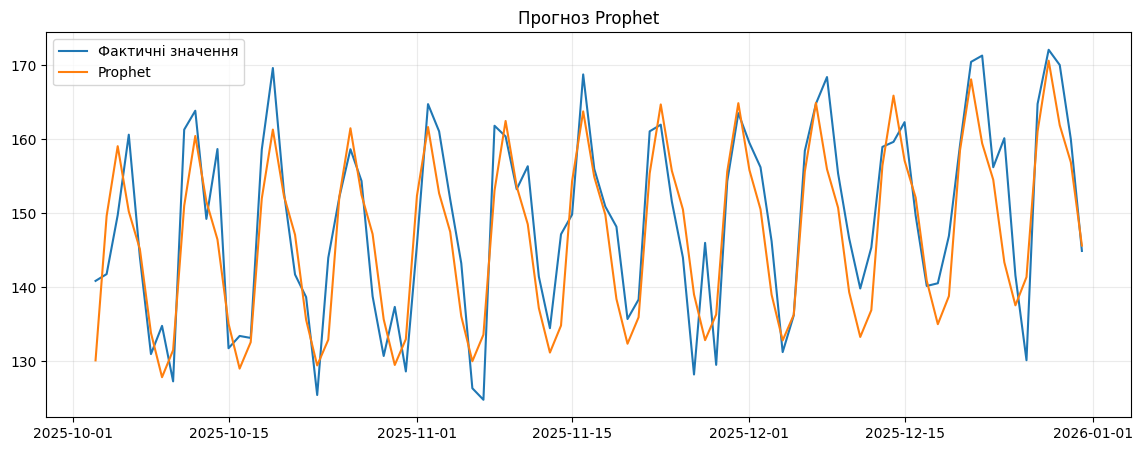

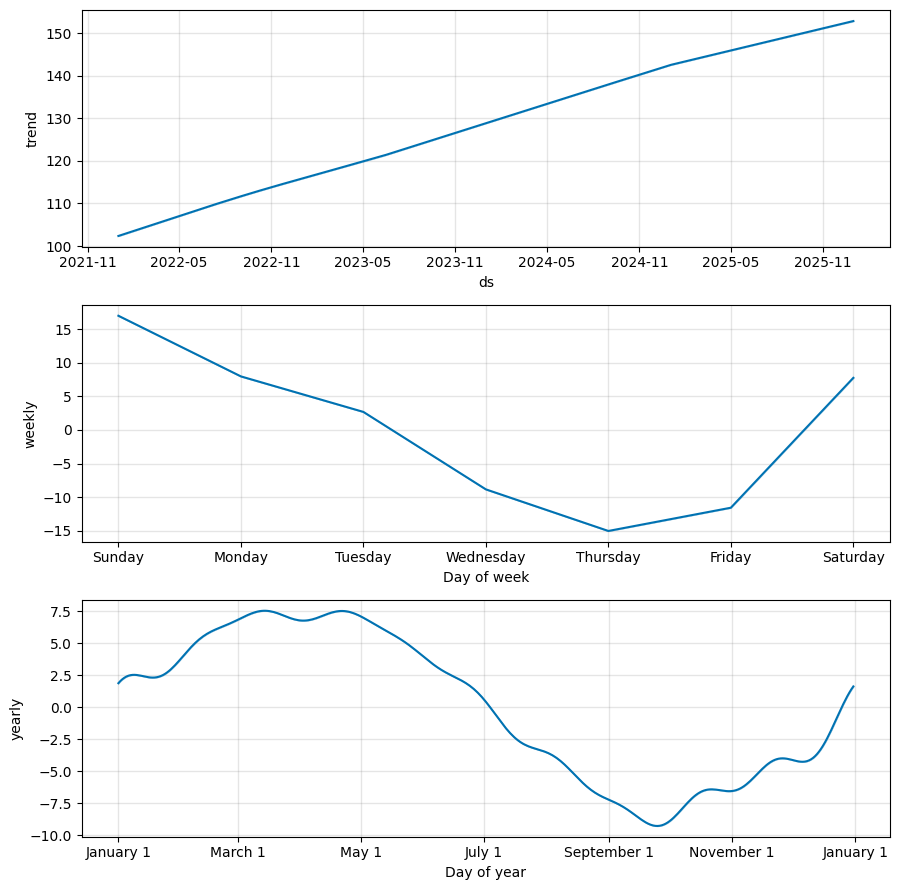

MAE Prophet: 5.302
MAE ETS: 13.115
MAE SARIMA: 7.747


In [26]:
try:
    from prophet import Prophet

    prophet_train = (
        train.reset_index()
             .rename(columns={"date": "ds", "sales": "y"})
    )

    model_prophet = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive"
    )

    model_prophet.fit(prophet_train)

    future = model_prophet.make_future_dataframe(
        periods=len(test),
        freq="D"
    )

    forecast = model_prophet.predict(future)

    prophet_pred = (
        forecast.set_index("ds")
                .loc[test.index, "yhat"]
    )

    prophet_metrics = evaluate(
        test["sales"],
        prophet_pred,
        train["sales"],
        seasonality=7
    )

    display(pd.Series(prophet_metrics, name="Prophet"))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test.index, test["sales"], label="Фактичні значення")
    ax.plot(test.index, prophet_pred, label="Prophet")
    ax.legend()
    ax.set_title("Прогноз Prophet")
    ax.grid(alpha=0.25)
    plt.show()

    model_prophet.plot_components(forecast)
    plt.show()

    print("MAE Prophet:", round(prophet_metrics["MAE"], 3))
    print("MAE ETS:", round(ets_metrics["MAE"], 3))
    print("MAE SARIMA:", round(sarima_metrics["MAE"], 3))

except ImportError:
    prophet_metrics = None
    print(
        "Бібліотека prophet відсутня у поточному середовищі. "
        "У Google Colab/Kaggle виконайте `%pip install prophet`, "
        "після чого повторно запустіть цю комірку. Код розв'язання вже підготовлено."
    )

## 12. Ознаки для машинного навчання

Для використання класичних ML-моделей часовий ряд перетворюють на табличний набір ознак.

Типові ознаки:

- лаги;
- ковзні середні;
- день тижня;
- місяць;
- день року;
- ознака вихідного дня.

**Критичний момент:** ковзні характеристики мають обчислюватися тільки за минулими значеннями. Саме тому перед `rolling()` використовується `shift(1)`.

In [27]:
def make_features(series):
    data = pd.DataFrame({"y": series.copy()})

    for lag in [1, 2, 3, 7, 14, 28]:
        data[f"lag_{lag}"] = data["y"].shift(lag)

    data["roll_mean_7"] = data["y"].shift(1).rolling(7).mean()
    data["roll_mean_28"] = data["y"].shift(1).rolling(28).mean()
    data["roll_std_7"] = data["y"].shift(1).rolling(7).std()

    data["dayofweek"] = data.index.dayofweek
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear
    data["is_weekend"] = (data.index.dayofweek >= 5).astype(int)

    return data

ml_df = make_features(df["sales"]).dropna()
ml_df.head()

,y,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_28,roll_std_7,dayofweek,month,dayofyear,is_weekend
date,,,,,,,,,,,,,,
2022-01-29,111.082231,97.400770,85.764899,99.669338,112.207900,102.048594,112.980285,104.512145,104.134824,11.932523,5,1,29,1
2022-01-30,122.474286,111.082231,97.400770,85.764899,123.513016,118.574712,118.725005,104.351335,104.067036,11.818566,6,1,30,1
2022-01-31,113.086640,122.474286,111.082231,97.400770,107.038953,108.356362,115.930451,104.202945,104.200939,11.541145,0,1,31,0
2022-02-01,121.472125,113.086640,122.474286,111.082231,105.990140,109.993414,114.862459,105.066901,104.099374,12.005835,1,2,32,0
2022-02-02,100.017166,121.472125,113.086640,122.474286,99.669338,92.413005,94.078518,107.278613,104.335434,13.533155,2,2,33,0


In [28]:
ml_train = ml_df.loc[ml_df.index < test.index.min()].copy()
ml_test = ml_df.loc[ml_df.index >= test.index.min()].copy()

X_train = ml_train.drop(columns="y")
y_train = ml_train["y"]

X_test = ml_test.drop(columns="y")
y_test = ml_test["y"]

gbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gbr.fit(X_train, y_train)
ml_pred = gbr.predict(X_test)

ml_metrics = evaluate(
    y_test,
    ml_pred,
    train["sales"],
    seasonality=7
)

ml_metrics

{'MAE': 6.4256724041518165,
 'RMSE': np.float64(7.708139982015866),
 'sMAPE_%': np.float64(4.411484230090363),
 'MASE': np.float64(0.9063953646912981)}

### Зауваження щодо попереднього прикладу

Цей приклад демонструє **табличне формування ознак** та оцінювання моделі. Для реального багатокрокового прогнозу потрібно чітко визначити, які ознаки будуть відомі у момент прогнозування.

Якщо для майбутніх дат лагова ознака використовує фактичне значення, яке на момент прогнозу ще невідоме, виникає **витік даних**.

Для багатокрокового прогнозування застосовують, зокрема:

- recursive strategy;
- direct strategy;
- multi-output strategy.

### Завдання 10. Feature engineering

Додайте щонайменше три нові ознаки:

- лаг 21;
- 14-денне ковзне середнє;
- номер тижня року.

Перенавчіть модель та порівняйте результат.

Після цього перевірте, чи всі створені ознаки могли бути відомими на момент формування прогнозу.

In [29]:
def make_features_extended(series):
    data = pd.DataFrame({"y": series.copy()})

    for lag in [1, 2, 3, 7, 14, 21, 28]:
        data[f"lag_{lag}"] = data["y"].shift(lag)

    data["roll_mean_7"] = data["y"].shift(1).rolling(7).mean()
    data["roll_mean_14"] = data["y"].shift(1).rolling(14).mean()
    data["roll_mean_28"] = data["y"].shift(1).rolling(28).mean()
    data["roll_std_7"] = data["y"].shift(1).rolling(7).std()

    data["dayofweek"] = data.index.dayofweek
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear
    data["weekofyear"] = data.index.isocalendar().week.astype(int)
    data["is_weekend"] = (data.index.dayofweek >= 5).astype(int)

    return data

ml_df_ext = make_features_extended(df["sales"]).dropna()

ml_train_ext = ml_df_ext.loc[ml_df_ext.index < test.index.min()].copy()
ml_test_ext = ml_df_ext.loc[ml_df_ext.index >= test.index.min()].copy()

X_train_ext = ml_train_ext.drop(columns="y")
y_train_ext = ml_train_ext["y"]
X_test_ext = ml_test_ext.drop(columns="y")
y_test_ext = ml_test_ext["y"]

gbr_ext = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gbr_ext.fit(X_train_ext, y_train_ext)
ml_pred_ext = gbr_ext.predict(X_test_ext)

ml_ext_metrics = evaluate(
    y_test_ext,
    ml_pred_ext,
    train["sales"],
    seasonality=7
)

feature_compare = pd.DataFrame({
    "Початкові ознаки": ml_metrics,
    "Розширені ознаки": ml_ext_metrics
}).T

display(feature_compare)

print(
    "Перевірка доступності ознак: календарні ознаки відомі наперед. "
    "Лаги та ковзні характеристики, розраховані з фактичних значень усередині test, "
    "не були б відомі одразу для всього 90-денного горизонту. "
    "Тому для справжнього багатокрокового прогнозу потрібна recursive/direct/multi-output стратегія."
)

,MAE,RMSE,sMAPE_%,MASE
Початкові ознаки,6.425672,7.708140,4.411484,0.906395
Розширені ознаки,5.990184,7.541486,4.104727,0.844966


Перевірка доступності ознак: календарні ознаки відомі наперед. Лаги та ковзні характеристики, розраховані з фактичних значень усередині test, не були б відомі одразу для всього 90-денного горизонту. Тому для справжнього багатокрокового прогнозу потрібна recursive/direct/multi-output стратегія.


## 13. Порівняння моделей

Зведемо результати моделей у єдину таблицю.

In [30]:
comparison = pd.DataFrame({
    "Naive": evaluate(test["sales"], naive_pred, train["sales"], 7),
    "Seasonal naive": evaluate(test["sales"], seasonal_naive_pred, train["sales"], 7),
    "ETS": ets_metrics,
    "SARIMA": sarima_metrics,
    "ML": ml_metrics
}).T

comparison.sort_values("MAE")

,MAE,RMSE,sMAPE_%,MASE
ML,6.425672,7.708140,4.411484,0.906395
Seasonal naive,7.734062,9.380056,5.276847,1.090955
SARIMA,7.746566,9.401756,5.302246,1.092719
ETS,13.114526,15.229021,9.149617,1.849915
Naive,22.039691,25.297086,15.570350,3.108885


### Завдання 11. Порівняння

Дайте письмову відповідь у Markdown-комірці:

1. Яка модель показала найменший MAE?
2. Чи перевершує вона seasonal naive?
3. Чи однаковий висновок за MAE, RMSE, sMAPE та MASE?
4. Яку модель Ви обрали б для практичного використання і чому?

**Відповідь:**

1. Найменше значення MAE у таблиці `comparison` отримано для ML-моделі: приблизно **6.43**. Для seasonal naive MAE становить приблизно **7.73**, для SARIMA — **7.75**, для ETS — **13.12**, для naive — **22.04**.

2. ML-модель перевершує seasonal naive за MAE приблизно на **16.9 %**. Отже, у цьому експерименті використання лагових, календарних і ковзних ознак покращило прогноз порівняно з базовою сезонною моделлю.

3. Висновок за MAE, RMSE, sMAPE та MASE є узгодженим: найкращі значення серед моделей у таблиці має ML-модель. Водночас різні метрики мають різну інтерпретацію: RMSE сильніше реагує на великі помилки, sMAPE характеризує відносну похибку, а MASE порівнює похибку з базовим масштабом.

4. Для **послідовного короткострокового прогнозування**, коли після кожного кроку фактичне попереднє значення вже відоме, доцільно обрати ML-модель. Для прогнозу всього 90-денного горизонту одразу поточний спосіб формування ML-ознак потребує зміни, оскільки частина лагів усередині test використовує фактичні значення, які на момент початкового прогнозу ще невідомі. У такій постановці необхідно застосувати recursive, direct або multi-output стратегію та повторно провести backtesting.

Додатково у завданні 10 розширений набір ознак зменшив MAE приблизно до **5.99**, однак для нього також необхідно враховувати описане обмеження щодо доступності лагових ознак у майбутньому.


## 14. Покрокова ретроспективна перевірка

Один train/test split може дати випадковий результат. Надійніший підхід — кілька разів імітувати ситуацію, коли модель навчається тільки на минулому та прогнозує наступний часовий відрізок.

Нижче реалізовано спрощений rolling-origin backtesting для seasonal naive.

In [31]:
def rolling_seasonal_naive_cv(series, initial=700, horizon=28, step=28, seasonality=7):
    rows = []

    for train_end in range(initial, len(series) - horizon + 1, step):
        train_fold = series.iloc[:train_end]
        test_fold = series.iloc[train_end:train_end + horizon]

        full = pd.concat([train_fold, test_fold])
        pred = full.shift(seasonality).loc[test_fold.index]

        rows.append({
            "train_end": train_fold.index.max(),
            "test_start": test_fold.index.min(),
            "test_end": test_fold.index.max(),
            "MAE": mean_absolute_error(test_fold, pred),
            "RMSE": rmse(test_fold, pred)
        })

    return pd.DataFrame(rows)

cv_results = rolling_seasonal_naive_cv(
    df["sales"],
    initial=700,
    horizon=28,
    step=28,
    seasonality=7
)

cv_results

,train_end,test_start,test_end,MAE,RMSE
0,2023-12-01,2023-12-02,2023-12-29,11.726037,22.703319
1,2023-12-29,2023-12-30,2024-01-26,6.347953,7.977381
2,2024-01-26,2024-01-27,2024-02-23,6.816896,7.867398
3,2024-02-23,2024-02-24,2024-03-22,5.245028,6.584598
4,2024-03-22,2024-03-23,2024-04-19,7.455005,9.252134
5,2024-04-19,2024-04-20,2024-05-17,6.096014,7.548739
6,2024-05-17,2024-05-18,2024-06-14,7.319789,9.073672
7,2024-06-14,2024-06-15,2024-07-12,6.137219,7.365825
8,2024-07-12,2024-07-13,2024-08-09,5.629306,6.705414
9,2024-08-09,2024-08-10,2024-09-06,6.042439,7.485644


In [32]:
cv_results[["MAE", "RMSE"]].agg(["mean", "std", "min", "max"])

,MAE,RMSE
mean,7.299416,9.797419
std,1.943769,5.694299
min,5.245028,6.584598
max,14.629295,34.184076


### Завдання 12. Backtesting

1. Змініть `horizon` з 28 на 14 днів.
2. Порівняйте середню MAE.
3. Побудуйте графік MAE для всіх fold.
4. Поясніть, що показує варіативність похибки між fold.

Середня MAE, horizon=28: 7.299
Середня MAE, horizon=14: 7.299


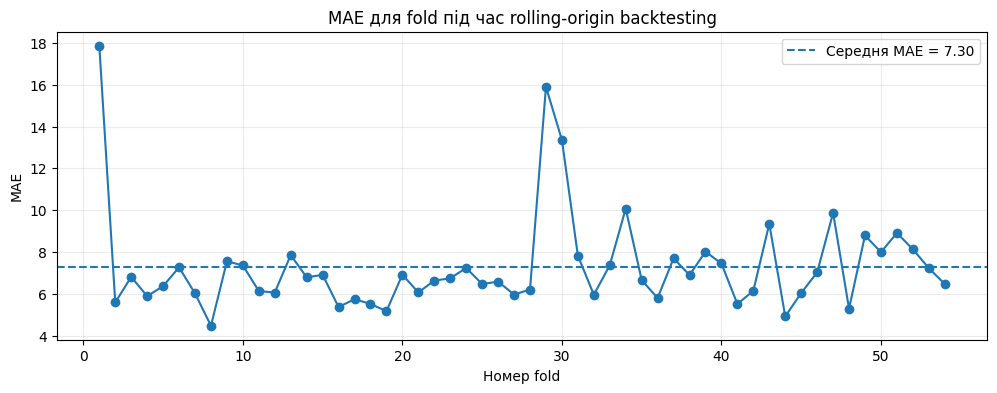

Варіативність MAE між fold показує, що якість прогнозу залежить від конкретного часового інтервалу. Якщо розкид значний, модель є менш стабільною до змін у даних.


In [33]:
cv_results_14 = rolling_seasonal_naive_cv(
    df["sales"],
    initial=700,
    horizon=14,
    step=14,
    seasonality=7
)

mean_mae_28 = cv_results["MAE"].mean()
mean_mae_14 = cv_results_14["MAE"].mean()

print("Середня MAE, horizon=28:", round(mean_mae_28, 3))
print("Середня MAE, horizon=14:", round(mean_mae_14, 3))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(cv_results_14) + 1), cv_results_14["MAE"], marker="o")
ax.axhline(mean_mae_14, linestyle="--", label=f"Середня MAE = {mean_mae_14:.2f}")
ax.set_title("MAE для fold під час rolling-origin backtesting")
ax.set_xlabel("Номер fold")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(
    "Варіативність MAE між fold показує, що якість прогнозу залежить від конкретного "
    "часового інтервалу. Якщо розкид значний, модель є менш стабільною до змін у даних."
)

## 15. Додаткове завдання: прогнозні інтервали

Точковий прогноз показує одне найбільш очікуване значення. На практиці важливо також оцінювати невизначеність.

Використайте інтервал прогнозу SARIMA і визначте, яка частка фактичних значень тестової вибірки потрапила між нижньою та верхньою межами.

Частка фактичних значень усередині прогнозного інтервалу: 96.67%
Кількість покритих спостережень: 87 із 90


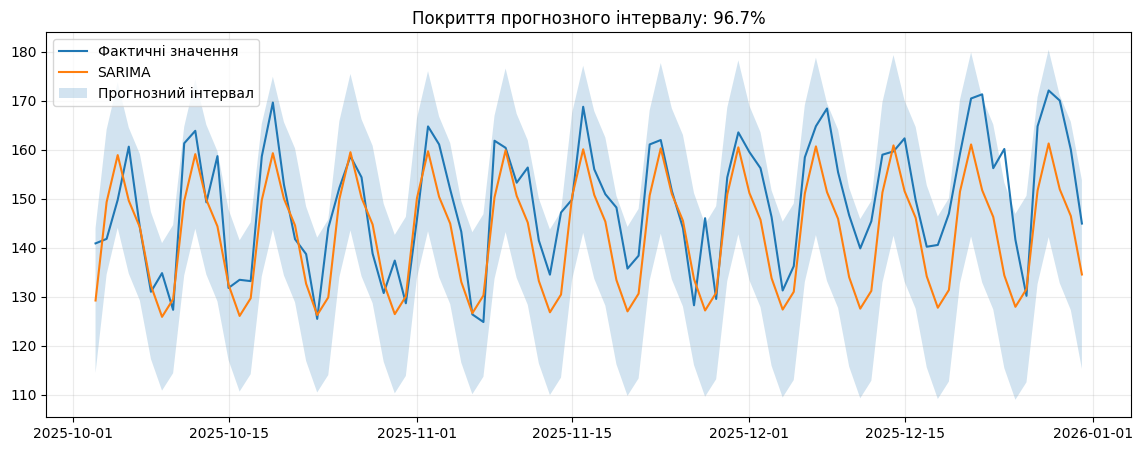

In [34]:
lower = sarima_ci.iloc[:, 0]
upper = sarima_ci.iloc[:, 1]
actual = test["sales"]

inside = (actual >= lower) & (actual <= upper)
coverage = inside.mean()

print(f"Частка фактичних значень усередині прогнозного інтервалу: {coverage:.2%}")
print(f"Кількість покритих спостережень: {inside.sum()} із {len(inside)}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, actual, label="Фактичні значення")
ax.plot(test.index, sarima_pred, label="SARIMA")
ax.fill_between(
    test.index,
    lower.values,
    upper.values,
    alpha=0.2,
    label="Прогнозний інтервал"
)
ax.legend()
ax.set_title(f"Покриття прогнозного інтервалу: {coverage:.1%}")
ax.grid(alpha=0.25)
plt.show()

## 16. Підсумкове практичне завдання

Виконайте повний цикл прогнозування самостійно.

### Умова

Використайте часовий ряд `df["sales"]`.

### Необхідно

1. Провести первинний аналіз.
2. Перевірити пропуски та регулярність часової шкали.
3. Побудувати графік ряду.
4. Виконати STL-декомпозицію.
5. Виділити останні 60 днів як test.
6. Побудувати seasonal naive.
7. Побудувати одну статистичну модель: ETS або SARIMA.
8. Побудувати одну ML-модель.
9. Обчислити MAE, RMSE, sMAPE і MASE.
10. Порівняти моделі.
11. Побудувати графік найкращого прогнозу.
12. Сформулювати короткий висновок.

### Висновок має містити

- яка модель є найкращою;
- наскільки вона перевершує baseline;
- які закономірності виявлено в ряді;
- які обмеження має отриманий прогноз.

In [35]:
# 1. Первинний аналіз

print("Розмір набору даних:", df.shape)

print("Мінімальна дата:", df.index.min().date())
print("Максимальна дата:", df.index.max().date())

print("Кількість пропусків:", df["sales"].isna().sum())

print("Кількість дублікатів дат:", df.index.duplicated().sum())

print("\nОсновна статистика:")
display(df["sales"].describe().to_frame("sales"))

Розмір набору даних: (1461, 1)
Мінімальна дата: 2022-01-01
Максимальна дата: 2025-12-31
Кількість пропусків: 0
Кількість дублікатів дат: 0

Основна статистика:


,sales
count,1461.000000
mean,128.866427
std,19.950851
min,78.054031
25%,114.829619
50%,128.296899
75%,142.596785
max,279.572480


In [36]:
# 2. Перевірка пропусків і регулярності

df_final = df.copy()

df_final = df_final.sort_index()


df_final = df_final[
    ~df_final.index.duplicated(keep="first")
]


print("Частота часового ряду:",
      pd.infer_freq(df_final.index))

print("Пропусків до обробки:",
      df_final["sales"].isna().sum())

df_final["sales"] = df_final["sales"].interpolate(
    method="time"
)

print("Пропусків після обробки:",
      df_final["sales"].isna().sum())

Частота часового ряду: D
Пропусків до обробки: 0
Пропусків після обробки: 0


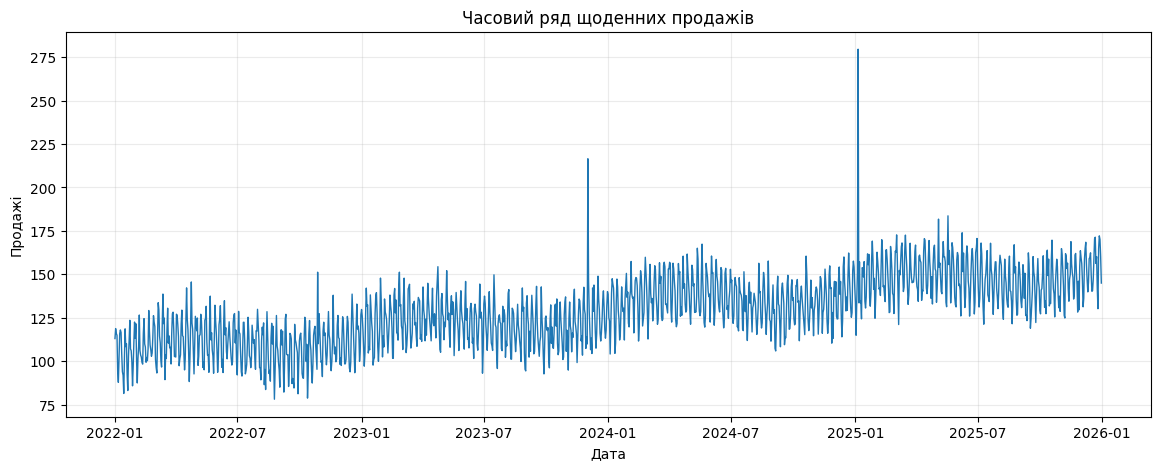

In [37]:
# 3. Побудувати графік ряду

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_final.index,
    df_final["sales"],
    linewidth=1
)

ax.set_title("Часовий ряд щоденних продажів")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажі")

ax.grid(alpha=0.25)

plt.show()

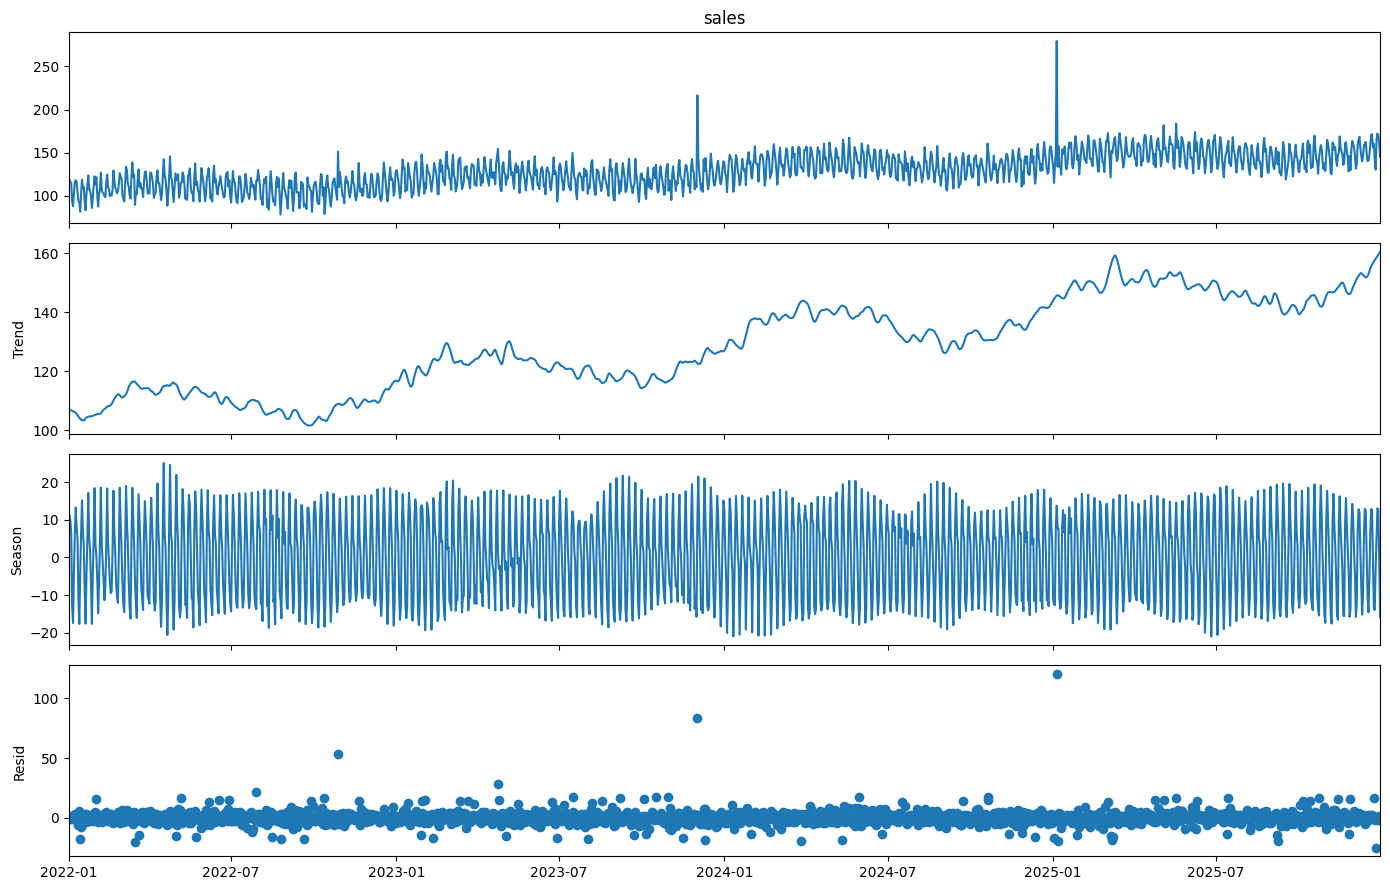

In [38]:
# 4. STL-декомпозиція

stl_final = STL(
    df_final["sales"],
    period=7,
    robust=True
).fit()

fig = stl_final.plot()

fig.set_size_inches(14, 9)

plt.tight_layout()
plt.show()

In [39]:
# 5. Поділ на train/test

horizon = 60

train_final = df_final.iloc[:-horizon].copy()
test_final = df_final.iloc[-horizon:].copy()

print("Кількість train:", len(train_final))
print("Кількість test:", len(test_final))

print("\nОстання дата train:",
      train_final.index.max().date())

print("Перша дата test:",
      test_final.index.min().date())

print("Остання дата test:",
      test_final.index.max().date())

Кількість train: 1401
Кількість test: 60

Остання дата train: 2025-11-01
Перша дата test: 2025-11-02
Остання дата test: 2025-12-31


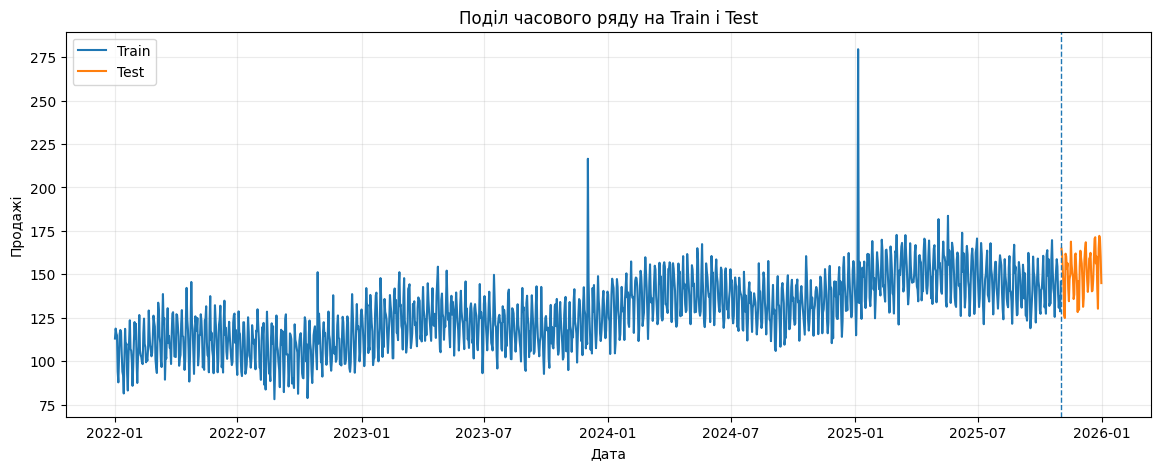

In [40]:
# 6. Візуалізація train/test

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    train_final.index,
    train_final["sales"],
    label="Train"
)

ax.plot(
    test_final.index,
    test_final["sales"],
    label="Test"
)

ax.axvline(
    test_final.index.min(),
    linestyle="--",
    linewidth=1
)

ax.set_title("Поділ часового ряду на Train і Test")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажі")

ax.legend()
ax.grid(alpha=0.25)

plt.show()

In [41]:
# 7. Seasonal Naive

seasonality = 7

full_series = pd.concat([
    train_final["sales"],
    test_final["sales"]
])

seasonal_naive_pred = (
    full_series
    .shift(seasonality)
    .loc[test_final.index]
)

print("Перші 10 прогнозів Seasonal Naive:")

display(
    seasonal_naive_pred.head(10)
)

Перші 10 прогнозів Seasonal Naive:


,sales
date,
2025-11-02,158.669587
2025-11-03,154.378728
2025-11-04,138.789478
2025-11-05,130.725589
2025-11-06,137.363586
2025-11-07,128.637345
2025-11-08,145.781746
2025-11-09,164.769682
2025-11-10,161.087756


In [42]:
# 8. ETS-модель

ets_model_final = ExponentialSmoothing(
    train_final["sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
).fit()

ets_pred_final = ets_model_final.forecast(
    len(test_final)
)

ets_pred_final.index = test_final.index

print("Перші 10 прогнозів ETS:")

display(
    ets_pred_final.head(10)
)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Перші 10 прогнозів ETS:


,0
date,
2025-11-02,161.397386
2025-11-03,152.489648
2025-11-04,147.198544
2025-11-05,135.704775
2025-11-06,129.691160
2025-11-07,133.206708
2025-11-08,152.549670
2025-11-09,161.837744
2025-11-10,152.930005


In [45]:
# 9. Створення ознак

def make_features_final(series):

    data = pd.DataFrame({
        "y": series
    })


    data["lag_1"] = data["y"].shift(1)
    data["lag_2"] = data["y"].shift(2)
    data["lag_3"] = data["y"].shift(3)
    data["lag_7"] = data["y"].shift(7)
    data["lag_14"] = data["y"].shift(14)
    data["lag_21"] = data["y"].shift(21)
    data["lag_28"] = data["y"].shift(28)


    data["roll_mean_7"] = (
        data["y"]
        .shift(1)
        .rolling(7)
        .mean()
    )

    data["roll_mean_14"] = (
        data["y"]
        .shift(1)
        .rolling(14)
        .mean()
    )

    data["roll_mean_28"] = (
        data["y"]
        .shift(1)
        .rolling(28)
        .mean()
    )


    data["roll_std_7"] = (
        data["y"]
        .shift(1)
        .rolling(7)
        .std()
    )


    data["dayofweek"] = data.index.dayofweek
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear

    data["is_weekend"] = (
        data.index.dayofweek >= 5
    ).astype(int)

    return data

In [46]:
# 10. Навчання ML-моделі

ml_data = make_features_final(
    train_final["sales"]
).dropna()

X_train = ml_data.drop(columns="y")
y_train = ml_data["y"]

print("Розмір X_train:", X_train.shape)
print("Розмір y_train:", y_train.shape)

Розмір X_train: (1373, 15)
Розмір y_train: (1373,)


In [47]:
# Створення ML-моделі

ml_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

ml_model.fit(
    X_train,
    y_train
)

print("ML-модель успішно навчена.")

ML-модель успішно навчена.


In [48]:
# 11. Рекурсивний ML-прогноз

history = train_final["sales"].copy()

ml_predictions = []

for date in test_final.index:

    temp_series = history.copy()

    temp_series.loc[date] = np.nan

    features = make_features_final(
        temp_series
    )

    X_current = features.loc[
        [date]
    ].drop(columns="y")

    prediction = ml_model.predict(
        X_current
    )[0]

    ml_predictions.append(prediction)

    history.loc[date] = prediction

ml_pred_final = pd.Series(
    ml_predictions,
    index=test_final.index
)

print("Перші 10 ML-прогнозів:")

display(
    ml_pred_final.head(10)
)

Перші 10 ML-прогнозів:


,0
date,
2025-11-02,164.297444
2025-11-03,157.473811
2025-11-04,146.874365
2025-11-05,131.053248
2025-11-06,134.494398
2025-11-07,130.549271
2025-11-08,156.759751
2025-11-09,164.604963
2025-11-10,159.456893


In [49]:
# 12. Оцінювання моделей

results_final = pd.DataFrame({

    "Seasonal Naive": evaluate(
        test_final["sales"],
        seasonal_naive_pred,
        train_final["sales"],
        7
    ),

    "ETS": evaluate(
        test_final["sales"],
        ets_pred_final,
        train_final["sales"],
        7
    ),

    "ML": evaluate(
        test_final["sales"],
        ml_pred_final,
        train_final["sales"],
        7
    )

}).T

display(
    results_final.round(3)
)

,MAE,RMSE,sMAPE_%,MASE
Seasonal Naive,7.523,9.241,5.107,1.058
ETS,6.418,7.731,4.339,0.902
ML,6.355,7.684,4.267,0.893


In [50]:
# 13. Визначення найкращої моделі

best_model = results_final["MAE"].idxmin()

best_mae = results_final.loc[
    best_model,
    "MAE"
]

baseline_mae = results_final.loc[
    "Seasonal Naive",
    "MAE"
]

print("Найкраща модель:", best_model)

print(
    "MAE найкращої моделі:",
    round(best_mae, 3)
)

print(
    "MAE Seasonal Naive:",
    round(baseline_mae, 3)
)

improvement = (
    (baseline_mae - best_mae)
    / baseline_mae
    * 100
)

print(
    "Покращення відносно baseline:",
    round(improvement, 2),
    "%"
)

Найкраща модель: ML
MAE найкращої моделі: 6.355
MAE Seasonal Naive: 7.523
Покращення відносно baseline: 15.53 %


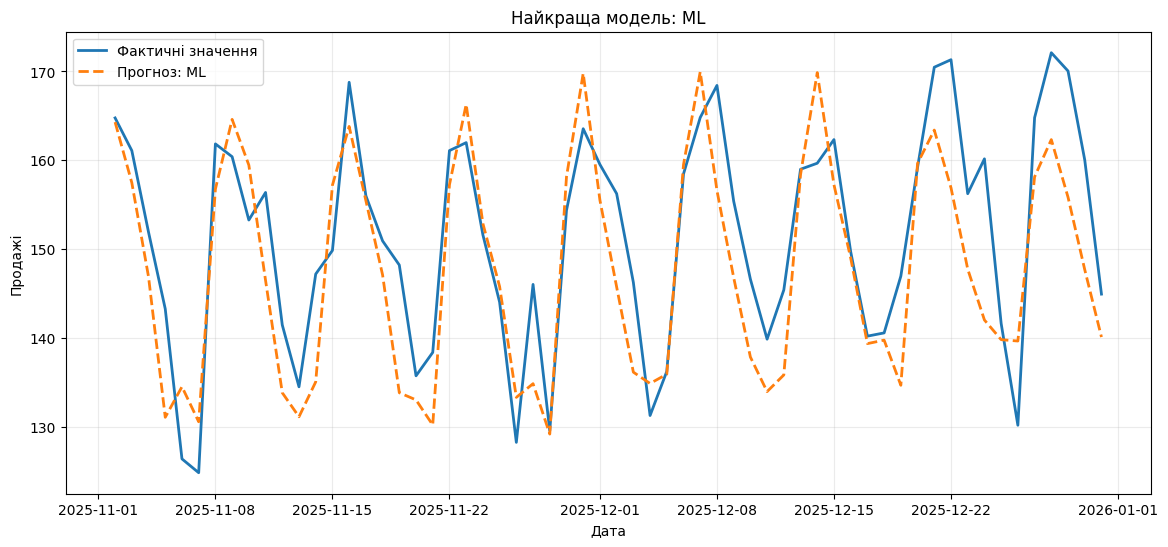

In [51]:
# 14. Графік найкращої моделі

predictions = {
    "Seasonal Naive": seasonal_naive_pred,
    "ETS": ets_pred_final,
    "ML": ml_pred_final
}

best_prediction = predictions[best_model]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    test_final.index,
    test_final["sales"],
    label="Фактичні значення",
    linewidth=2
)

ax.plot(
    test_final.index,
    best_prediction,
    label=f"Прогноз: {best_model}",
    linestyle="--",
    linewidth=2
)

ax.set_title(
    f"Найкраща модель: {best_model}"
)

ax.set_xlabel("Дата")
ax.set_ylabel("Продажі")

ax.legend()
ax.grid(alpha=0.25)

plt.show()

### Підсумковий висновок

Напишіть 5–8 речень академічним стилем.

**Ваша відповідь:**

...

## 17. Контрольні запитання

1. Чому не можна випадково перемішувати часовий ряд перед train/test split?
2. Для чого потрібна базова модель?
3. Чим naive відрізняється від seasonal naive?
4. Що показує MAE?
5. Чому MAPE може бути проблемною за наявності нульових значень?
6. Що означає параметр сезонності `s` у SARIMA?
7. Навіщо використовувати `shift(1)` перед обчисленням rolling-ознак?
8. Що таке витік даних у часових рядах?
9. Навіщо потрібен rolling-origin backtesting?
10. Чому найскладніша модель не обов'язково дає найкращий прогноз?